**ST5230 final project: Do LLMs exhibit systematic decision instability under meaning-presing paraphrases, and is this instability due to paraphrase sensitivity or inherent decision boundary ambiguity?**

In [ ]:
from openai import OpenAI
import pandas as pd

client = OpenAI(api_key="sk-###")


df = pd.read_csv("Source_data_yelp_300.csv")

def paraphrase(text):
    response = client.chat.completions.create(
        model="gpt-4o",
        temperature=0.7,
        messages=[
            {"role": "user", "content": f"""
Rewrite the following sentence by changing the wording while strictly preserving its original meaning and sentiment.
Do not make it more positive or more negative. Keep the same intensity.

Sentence:
{text}

Paraphrase:
"""}
        ]
    )
    return response.choices[0].message.content.strip()

df["paraphrase"] = df["text"].apply(paraphrase)

df.to_csv("yelp_with_paraphrase.csv", index=False)

In [ ]:
!pip install sentence-transformers

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd

df = pd.read_csv("yelp_with_paraphrase.csv")

model = SentenceTransformer('all-MiniLM-L6-v2')

emb1 = model.encode(df["text"].tolist(), batch_size=32)
emb2 = model.encode(df["paraphrase"].tolist(), batch_size=32)

similarities = cosine_similarity(emb1, emb2).diagonal()

df["similarity"] = similarities

# threshold
df = df[df["similarity"] > 0.85]

print("After embedding filter:", len(df))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

After embedding filter: 226


In [ ]:
from openai import OpenAI
import time

client = OpenAI(api_key="sk-###")

def judge_pair(text, para):
    try:
        response = client.chat.completions.create(
            model="gpt-4o-mini",
            temperature=0,
            messages=[
                {"role": "user", "content": f"""
You are a strict evaluator.

Determine whether the following two sentences have:
1. The same meaning
2. The same sentiment (including strength)

Original: "{text}"
Paraphrase: "{para}"

Answer ONLY with one word:
YES or NO
"""}
            ]
        )
        return response.choices[0].message.content.strip()
    except:
        return "NO"

results = []
for i, row in df.iterrows():
    res = judge_pair(row["text"], row["paraphrase"])
    results.append(res)
    time.sleep(0.3)

df["llm_valid"] = results

# only keep YES
df = df[df["llm_valid"] == "YES"]

print("After LLM filter:", len(df))


After LLM filter: 200


NameError: name 'df_final' is not defined

In [ ]:
final_filename = "final_validated_dataset.csv"
df.to_csv(final_filename, index=False)
print(f"Success! Final file saved as: {final_filename}")

Success! Final file saved as: final_validated_dataset.csv


In [ ]:
pip uninstall mistralai -y

Found existing installation: mistralai 2.1.3
Uninstalling mistralai-2.1.3:
  Successfully uninstalled mistralai-2.1.3


In [ ]:
pip install mistralai==0.4.2

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.9/41.9 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 133.1/133.1 kB 6.5 MB/s eta 0:00:00
  Attempting uninstall: orjson
    Found existing installation: orjson 3.11.7
    Uninstalling orjson-3.11.7:
      Successfully uninstalled orjson-3.11.7
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
langgraph-sdk 0.3.11 requires orjson>=3.11.5, but you have orjson 3.10.18 which is incompatible.


In [ ]:
import pandas as pd
import time
import collections
from openai import OpenAI
from mistralai.client import MistralClient
from mistralai.models.chat_completion import ChatMessage

# ===== API =====
gpt_client = OpenAI(api_key="sk-###")
mistral_client = MistralClient(api_key="iAh###")

# ===== Prompt =====
PROMPT = """
Classify the sentiment of the following sentence into one of three labels:
Positive, Neutral, or Negative.

Sentence:
"{text}"

Answer with only one word: Positive, Neutral, or Negative.
"""

# ===== multiple sampling function =====
def sample_gpt(text, n=5):
    results = []
    for _ in range(n):
        try:
            res = gpt_client.chat.completions.create(
                model="gpt-4o-mini",
                temperature=0.7,
                messages=[{"role": "user", "content": PROMPT.format(text=text)}]
            )
            results.append(res.choices[0].message.content.strip())
        except:
            continue
    return results


def sample_mistral(text, n=5):
    results = []
    for _ in range(n):
        try:
            res = mistral_client.chat(
                model="mistral-small-latest",
                temperature=0.7,
                messages=[ChatMessage(role="user", content=PROMPT.format(text=text))]
            )
            results.append(res.choices[0].message.content.strip())
        except:
            continue
    return results


# ===== Calculate Confidence Score =====
def get_confidence(labels):
    if len(labels) == 0:
        return 0
    counter = collections.Counter(labels)
    most_common = counter.most_common(1)[0][1]
    return most_common / len(labels)


# ===== Main work =====
df = pd.read_csv("final_validated_dataset.csv")

gpt_orig_labels_all = []
gpt_para_labels_all = []
mis_orig_labels_all = []
mis_para_labels_all = []

gpt_orig_conf = []
gpt_para_conf = []
mis_orig_conf = []
mis_para_conf = []

for i, row in df.iterrows():
    text = row["text"]
    para = row["paraphrase"]

    # ===== GPT =====
    gpt_orig = sample_gpt(text, n=5)
    gpt_para = sample_gpt(para, n=5)

    # ===== Mistral =====
    mis_orig = sample_mistral(text, n=5)
    mis_para = sample_mistral(para, n=5)

    # ===== Save labels =====
    gpt_orig_labels_all.append(gpt_orig)
    gpt_para_labels_all.append(gpt_para)
    mis_orig_labels_all.append(mis_orig)
    mis_para_labels_all.append(mis_para)

    # ===== Conf =====
    gpt_orig_conf.append(get_confidence(gpt_orig))
    gpt_para_conf.append(get_confidence(gpt_para))
    mis_orig_conf.append(get_confidence(mis_orig))
    mis_para_conf.append(get_confidence(mis_para))


    # ===== Saving =====
    if i % 10 == 0:
    df.to_csv("backup_results.csv", index=False)
    print(f"Saved at {i}")

    print(f"Processed {i}")
    time.sleep(0.5)


# ===== input csv =====
df["gpt_orig_labels"] = gpt_orig_labels_all
df["gpt_para_labels"] = gpt_para_labels_all
df["mis_orig_labels"] = mis_orig_labels_all
df["mis_para_labels"] = mis_para_labels_all

df["gpt_orig_conf"] = gpt_orig_conf
df["gpt_para_conf"] = gpt_para_conf
df["mis_orig_conf"] = mis_orig_conf
df["mis_para_conf"] = mis_para_conf


# ===== majority vote label =====
def majority_label(labels):
    if len(labels) == 0:
        return "ERROR"
    return collections.Counter(labels).most_common(1)[0][0]


df["gpt_orig_pred"] = df["gpt_orig_labels"].apply(majority_label)
df["gpt_para_pred"] = df["gpt_para_labels"].apply(majority_label)

df["mis_orig_pred"] = df["mis_orig_labels"].apply(majority_label)
df["mis_para_pred"] = df["mis_para_labels"].apply(majority_label)


# ===== flip =====
df["gpt_flip"] = df["gpt_orig_pred"] != df["gpt_para_pred"]
df["mis_flip"] = df["mis_orig_pred"] != df["mis_para_pred"]


# ===== Save file =====
df.to_csv("full_results_with_confidence.csv", index=False)

Processed 0
Processed 1
Processed 2
Processed 3
Processed 4
Processed 5
Processed 6
Processed 7
Processed 8
Processed 9
Processed 10
Processed 11
Processed 12
Processed 13
Processed 14
Processed 15
Processed 16
Processed 17
Processed 18
Processed 19
Processed 20
Processed 21
Processed 22
Processed 23
Processed 24
Processed 25
Processed 26
Processed 27
Processed 28
Processed 29
Processed 30
Processed 31
Processed 32
Processed 33
Processed 34
Processed 35
Processed 36
Processed 37
Processed 38
Processed 39
Processed 40
Processed 41
Processed 42
Processed 43
Processed 44
Processed 45
Processed 46
Processed 47
Processed 48
Processed 49
Processed 50
Processed 51
Processed 52
Processed 53
Processed 54
Processed 55
Processed 56
Processed 57
Processed 58
Processed 59
Processed 60
Processed 61
Processed 62
Processed 63
Processed 64
Processed 65
Processed 66
Processed 67
Processed 68
Processed 69
Processed 70
Processed 71
Processed 72
Processed 73
Processed 74
Processed 75
Processed 76
Processed

**Analysis**

In [ ]:
import pandas as pd

df = pd.read_csv("full_results_with_confidence.csv")

In [ ]:
gpt_flip_rate = df["gpt_flip"].mean()
mis_flip_rate = df["mis_flip"].mean()

print("GPT Flip Rate:", gpt_flip_rate)
print("Mistral Flip Rate:", mis_flip_rate)

GPT Flip Rate: 0.075
Mistral Flip Rate: 0.065


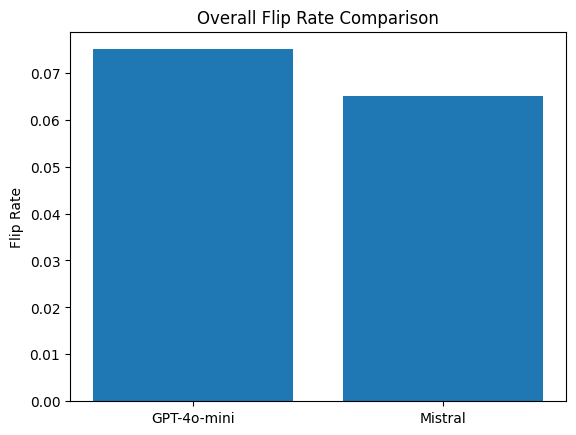

In [ ]:
import matplotlib.pyplot as plt

models = ["GPT-4o-mini", "Mistral"]
flip_rates = [gpt_flip_rate, mis_flip_rate]

plt.figure()
plt.bar(models, flip_rates)
plt.ylabel("Flip Rate")
plt.title("Overall Flip Rate Comparison")
plt.show()

Bootstrap Flip Rate Confidence Interval

In [ ]:
import numpy as np

def bootstrap_ci(data, n=1000):
    samples = []
    for _ in range(n):
        sample = data.sample(frac=1, replace=True)
        samples.append(sample.mean())
    return np.percentile(samples, [2.5, 97.5])

gpt_ci = bootstrap_ci(df["gpt_flip"])
mis_ci = bootstrap_ci(df["mis_flip"])

print("GPT CI:", gpt_ci)
print("Mistral CI:", mis_ci)

GPT CI: [0.04  0.115]
Mistral CI: [0.035 0.105]


Sentiment group analysis

In [ ]:
gpt_group = df.groupby("gpt_orig_pred")["gpt_flip"].mean()
mis_group = df.groupby("mis_orig_pred")["mis_flip"].mean()

print(gpt_group)
print(mis_group)

gpt_orig_pred
Negative    0.086022
Neutral     0.120000
Positive    0.048780
Name: gpt_flip, dtype: float64
mis_orig_pred
Negative    0.030000
Neutral     0.411765
Positive    0.036145
Name: mis_flip, dtype: float64


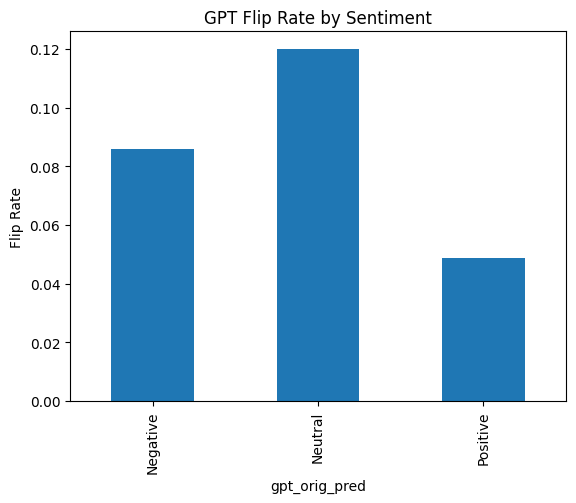

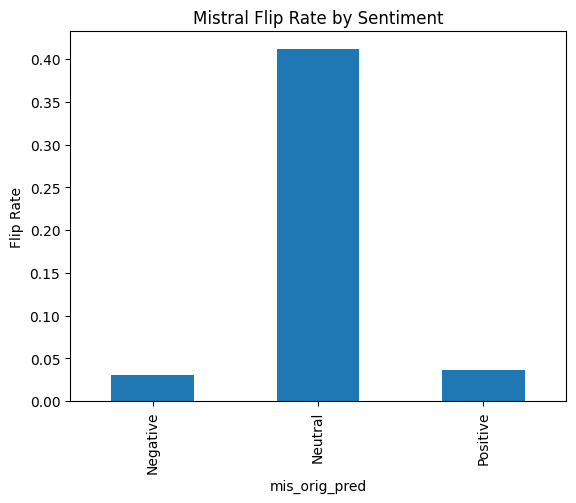

In [ ]:
plt.figure()
gpt_group.plot(kind="bar")
plt.title("GPT Flip Rate by Sentiment")
plt.ylabel("Flip Rate")
plt.show()

plt.figure()
mis_group.plot(kind="bar")
plt.title("Mistral Flip Rate by Sentiment")
plt.ylabel("Flip Rate")
plt.show()

boundry analysis

In [ ]:
df["gpt_conf_group"] = df["gpt_orig_conf"].apply(
    lambda x: "high" if x >= 0.8 else "low"
)

df["mis_conf_group"] = df["mis_orig_conf"].apply(
    lambda x: "high" if x >= 0.8 else "low"
)

In [ ]:
gpt_conf_analysis = df.groupby("gpt_conf_group")["gpt_flip"].mean()
mis_conf_analysis = df.groupby("mis_conf_group")["mis_flip"].mean()

print(gpt_conf_analysis)
print(mis_conf_analysis)

gpt_conf_group
high    0.065990
low     0.666667
Name: gpt_flip, dtype: float64
mis_conf_group
high    0.052632
low     0.300000
Name: mis_flip, dtype: float64


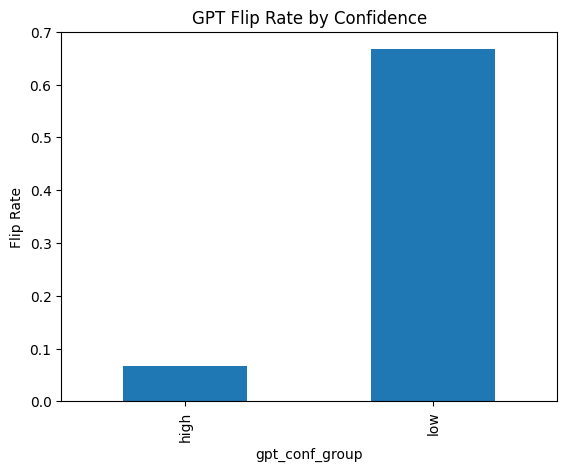

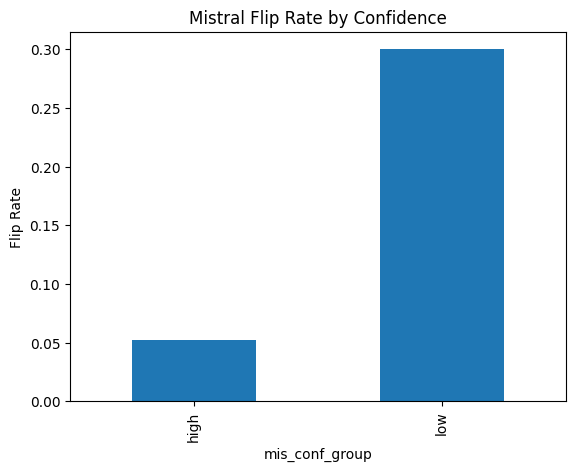

In [ ]:
plt.figure()
gpt_conf_analysis.plot(kind="bar")
plt.title("GPT Flip Rate by Confidence")
plt.ylabel("Flip Rate")
plt.show()

plt.figure()
mis_conf_analysis.plot(kind="bar")
plt.title("Mistral Flip Rate by Confidence")
plt.ylabel("Flip Rate")
plt.show()

model comparison: which sample have only one model flip

In [ ]:
df["only_gpt_flip"] = (df["gpt_flip"]) & (~df["mis_flip"])
df["only_mis_flip"] = (~df["gpt_flip"]) & (df["mis_flip"])

print("Only GPT flip:", df["only_gpt_flip"].mean())
print("Only Mistral flip:", df["only_mis_flip"].mean())

Only GPT flip: 0.055
Only Mistral flip: 0.045


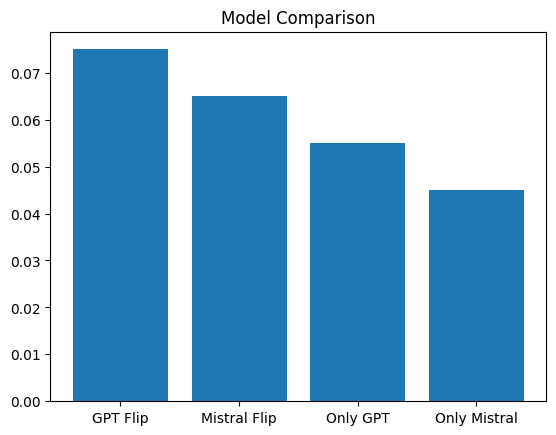

In [ ]:
values = [
    df["gpt_flip"].mean(),
    df["mis_flip"].mean(),
    df["only_gpt_flip"].mean(),
    df["only_mis_flip"].mean()
]

labels = ["GPT Flip", "Mistral Flip", "Only GPT", "Only Mistral"]

plt.figure()
plt.bar(labels, values)
plt.title("Model Comparison")
plt.show()

Confusion Matrix: Label shift

<Figure size 640x480 with 0 Axes>

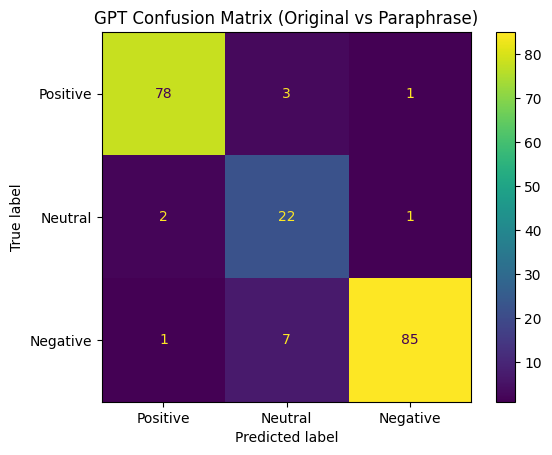

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

df = pd.read_csv("full_results_with_confidence.csv")

labels = ["Positive", "Neutral", "Negative"]

cm = confusion_matrix(
    df["gpt_orig_pred"],
    df["gpt_para_pred"],
    labels=labels
)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)

plt.figure()
disp.plot()
plt.title("GPT Confusion Matrix (Original vs Paraphrase)")
plt.show()

<Figure size 640x480 with 0 Axes>

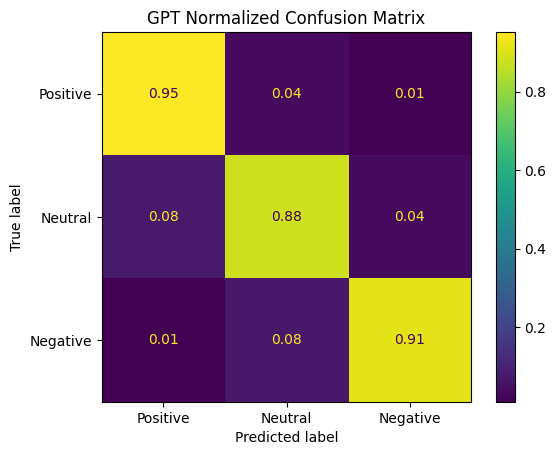

In [ ]:
import numpy as np

cm_norm = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]

disp = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=labels)

plt.figure()
disp.plot(values_format=".2f")
plt.title("GPT Normalized Confusion Matrix")
plt.show()

<Figure size 640x480 with 0 Axes>

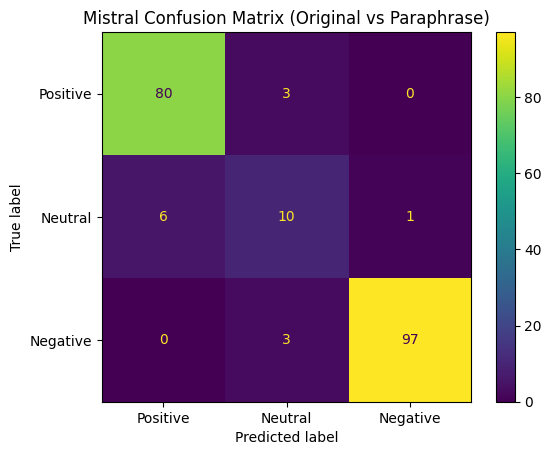

In [ ]:
cm_mis = confusion_matrix(
    df["mis_orig_pred"],
    df["mis_para_pred"],
    labels=labels
)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_mis, display_labels=labels)

plt.figure()
disp.plot()
plt.title("Mistral Confusion Matrix (Original vs Paraphrase)")
plt.show()

<Figure size 640x480 with 0 Axes>

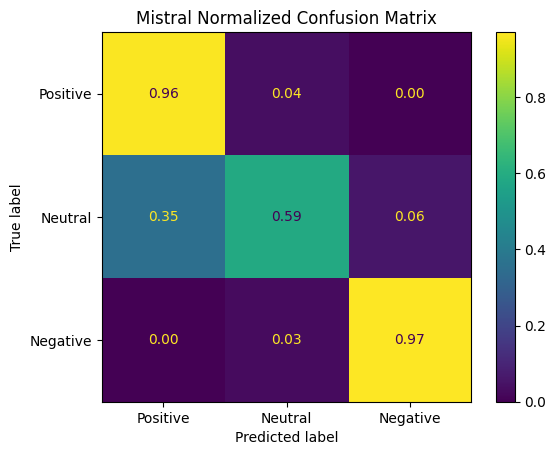

In [ ]:
import numpy as np

cm_mis_norm = cm_mis.astype("float") / cm_mis.sum(axis=1)[:, np.newaxis]

disp = ConfusionMatrixDisplay(confusion_matrix=cm_mis_norm, display_labels=labels)

plt.figure()
disp.plot(values_format=".2f")
plt.title("Mistral Normalized Confusion Matrix")
plt.show()

gpt_para_pred  Negative   Neutral  Positive
gpt_orig_pred                              
Negative       0.913978  0.075269  0.010753
Neutral        0.040000  0.880000  0.080000
Positive       0.012195  0.036585  0.951220


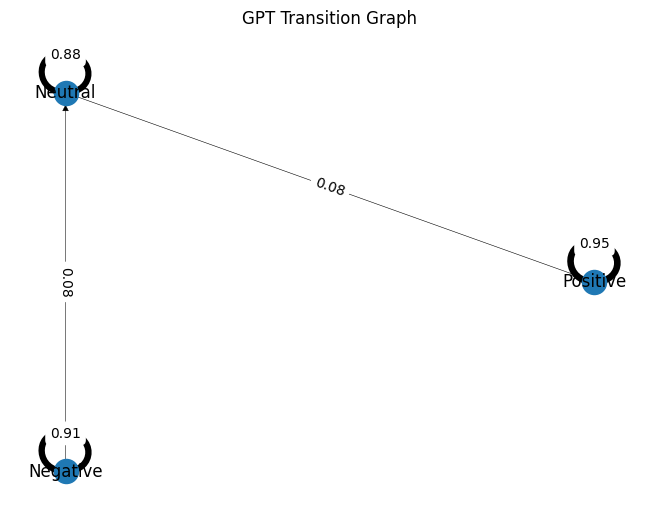

In [ ]:
import pandas as pd

df = pd.read_csv("full_results_with_confidence.csv")

labels = ["Positive", "Neutral", "Negative"]

# 计算 transition matrix
transition_counts = pd.crosstab(
    df["gpt_orig_pred"],
    df["gpt_para_pred"]
)

# 转成概率
transition_probs = transition_counts.div(transition_counts.sum(axis=1), axis=0)

print(transition_probs)

import networkx as nx
import matplotlib.pyplot as plt

G = nx.DiGraph()

# 加节点
for label in labels:
    G.add_node(label)

# 加边（只加非零）
for i in labels:
    for j in labels:
        prob = transition_probs.loc[i, j] if j in transition_probs.columns else 0
        if prob > 0.05:  # 过滤小概率
            G.add_edge(i, j, weight=prob)

# 画图
pos = nx.circular_layout(G)

edges = G.edges()
weights = [G[u][v]['weight'] * 5 for u, v in edges]  # 放大线条

plt.figure()
nx.draw(G, pos, with_labels=True, width=weights)
edge_labels = {(u, v): f"{G[u][v]['weight']:.2f}" for u, v in edges}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

plt.title("GPT Transition Graph")
plt.show()

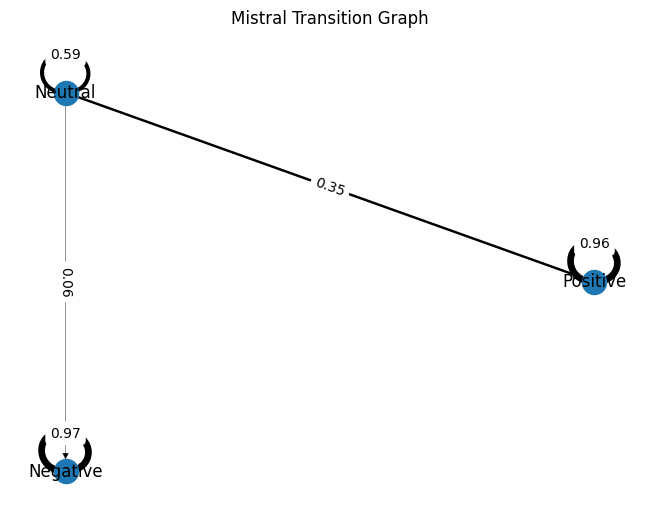

In [ ]:
transition_counts_mis = pd.crosstab(
    df["mis_orig_pred"],
    df["mis_para_pred"]
)

transition_probs_mis = transition_counts_mis.div(
    transition_counts_mis.sum(axis=1),
    axis=0
)

import networkx as nx
import matplotlib.pyplot as plt

labels = ["Positive", "Neutral", "Negative"]

G = nx.DiGraph()

# 加节点
for label in labels:
    G.add_node(label)

# 加边
for i in labels:
    for j in labels:
        if j in transition_probs_mis.columns:
            prob = transition_probs_mis.loc[i, j]
        else:
            prob = 0

        if prob > 0.05:  # 阈值
            G.add_edge(i, j, weight=prob)

# 布局
pos = nx.circular_layout(G)

edges = G.edges()
weights = [G[u][v]['weight'] * 5 for u, v in edges]

plt.figure()
nx.draw(G, pos, with_labels=True, width=weights)

edge_labels = {(u, v): f"{G[u][v]['weight']:.2f}" for u, v in edges}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

plt.title("Mistral Transition Graph")
plt.show()

qualitative analysis

In [ ]:
flips = df[df["gpt_flip"] == True]

sample_cases = flips.sample(10)

print(sample_cases[[
    "text",
    "paraphrase",
    "gpt_orig_pred",
    "gpt_para_pred"
]])

                                                  text  \
107  Waterfront Lowe's beats Monroeville Lowe's for...   
121  A fun place and lots to do but a bit pricy. $2...   
91   Steak 'n Shake's food is pretty good and the p...   
120  DAVE & BUSTERS!  It's a nice place to eat, hav...   
117  Chuckie Cheese for grown ups...Yeah, that coul...   
132  Little slow on the service and didn't have the...   
143  Rock Bottom is a chain brew pub one that, in m...   
85   The food is good. Unfortunately the service is...   
37   In all fairness - I did not see this dentist b...   
177  oddly enough, of all the giant eagles i have v...   

                                            paraphrase gpt_orig_pred  \
107  The lawn and garden section at Waterfront Lowe...      Negative   
121  It's an enjoyable spot with plenty of activiti...       Neutral   
91   Steak 'n Shake offers decent food, and the pri...      Negative   
120  DAVE & BUSTERS! It's a great spot for dining, ...      Positive   
1

In [ ]:
flip_df = df[df["gpt_flip"] == True]

sample_cases = flip_df[[
    "text",
    "paraphrase",
    "gpt_orig_pred",
    "gpt_para_pred",
    "gpt_orig_conf",
    "gpt_para_conf"
]]

def simple_shift(row):
    return f"{row['gpt_orig_pred']} → {row['gpt_para_pred']}"

sample_cases["shift"] = sample_cases.apply(simple_shift, axis=1)
sample_cases.to_csv("gpt_flip_cases_with_shift.csv", index=False)

from google.colab import files
files.download("gpt_flip_cases_with_shift.csv")

/tmp/ipykernel_6245/3752112366.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sample_cases["shift"] = sample_cases.apply(simple_shift, axis=1)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Error Taxonomy （LLM judgement）

In [ ]:
import pandas as pd

df = pd.read_csv("gpt_flip_cases_with_shift.csv")

from openai import OpenAI
import time

client = OpenAI(api_key="sk-###")

def classify_error(text, para):
    try:
        response = client.chat.completions.create(
            model="gpt-4o-mini",
            temperature=0,
            messages=[
                {
                    "role": "user",
                    "content": f"""
You are analyzing sentiment classification errors.

Original sentence:
"{text}"

Paraphrased sentence:
"{para}"

The sentiment label changed after paraphrasing.

Classify the main reason into ONE of the following categories:

1. Hedging / uncertainty
2. Intensity change
3. Negation change
4. Ambiguity / borderline
5. Structural rephrasing
6. Other

Answer with only the category name.
"""
                }
            ]
        )
        return response.choices[0].message.content.strip()

    except Exception as e:
        print("Error:", e)
        return "Other"

In [ ]:
df_sample = df.sample(min(20, len(df)), random_state=42)

df_sample["error_type"] = df_sample.apply(
    lambda row: classify_error(row["text"], row["paraphrase"]),
    axis=1
)

In [ ]:
error_types = []

for i, row in df.iterrows():
    label = classify_error(row["text"], row["paraphrase"])
    error_types.append(label)

    if i % 10 == 0:
        print(f"Processed {i}")

    time.sleep(0.3)  # 防止 rate limit

df["error_type"] = error_types

df.to_csv("gpt_flip_cases_with_error_type.csv", index=False)

Processed 0
Processed 10


In [ ]:
error_dist = df["error_type"].value_counts(normalize=True)

print(error_dist)

error_type
Intensity change         0.933333
Hedging / uncertainty    0.066667
Name: proportion, dtype: float64


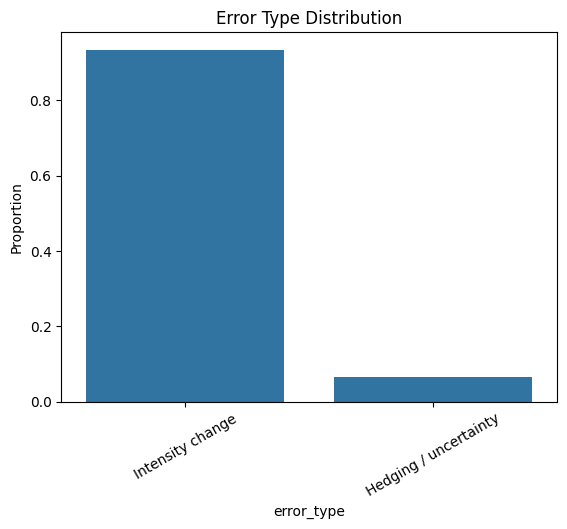

In [ ]:
import seaborn as sns

plt.figure()
sns.barplot(x=error_dist.index, y=error_dist.values)
plt.title("Error Type Distribution")
plt.ylabel("Proportion")
plt.xticks(rotation=30)
plt.show()